# Dataset loading:

In [56]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df=pd.read_csv('WineQuality.csv')

def detectTarget(df):
    totalRows=len(df)
    scores=[]

    for i,v in enumerate(df.columns):
        series=df[v]
        uniqueValues=series.nunique()
        dtype=series.dtype

        # print(f"Column: {v}, Unique Values: {uniqueValues}, Data Type: {dtype}")
        
        score=0

        if dtype=='object' or dtype=='category' or isinstance(dtype,pd.CategoricalDtype):
            score+=50
        
        if i==len(df.columns)-1:
            score+=40
        
        cardinalityRatio=uniqueValues/totalRows

        if cardinalityRatio > 0.9:
            score -= 100

        if uniqueValues <= 20: 
            score += 30
        elif uniqueValues <= 100:
            score += 10

        scores.append({'column': v, 'score': score, 'uniqueValues': uniqueValues, 'dtype': dtype})
    
    TargetCandidates=sorted(scores, key=lambda x: x['score'], reverse=True)
    bestVal=TargetCandidates[0]

    if bestVal['score'] < 40:
        return ({'type':'unsupervised', 'target':None})
    
    return {
        'type':'supervised',
        'target':bestVal['column'],
        'uniqueValues': bestVal['uniqueValues'],
        'dtype': bestVal['dtype']
    }
            

res=detectTarget(df)
print(res)
target=res['target']

if res['type']=='unsupervised':
    raise ValueError("This jupyter notebook is specifically designed for supervised learning, the dataset does not seem to have a clear given target column.")

if res['type']=='supervised' and res['uniqueValues']>20:
    raise ValueError("Detected more than 20 unique values which indicates a regression problem! this jupyter notebook is configured to work with classification problems")


{'type': 'supervised', 'target': 'quality', 'uniqueValues': 6, 'dtype': dtype('float64')}


# Feature type identification:

Numeric Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categorical Features: []
No missing data was detected
Target Class Distribution:
quality
5.0    681
6.0    638
7.0    199
4.0     53
8.0     18
3.0     10
Name: count, dtype: int64

Target Class Percentages:
quality
5.0    42.589118
6.0    39.899937
7.0    12.445278
4.0     3.314572
8.0     1.125704
3.0     0.625391
Name: proportion, dtype: float64


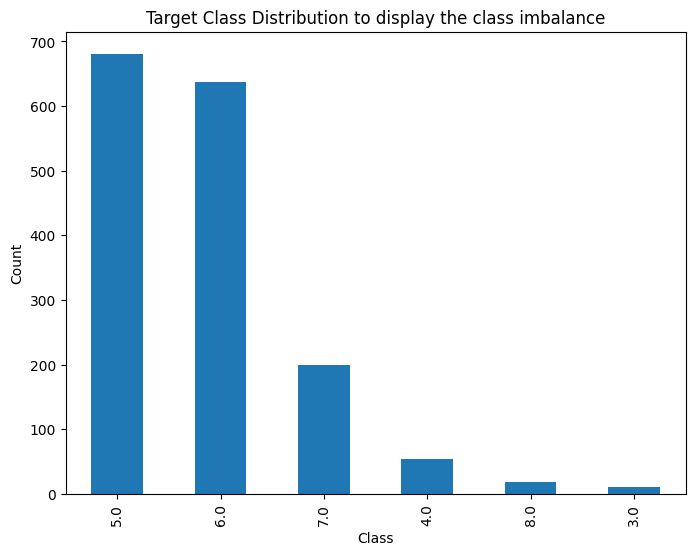

In [57]:
def featureIdentification(df, target):   
    features=df.drop(columns=[target])
    # print("Features:",)
    # print(features.columns.tolist())

    numericFeatures=features.select_dtypes(include=['number']).columns.tolist()
    categoricalFeatures=features.select_dtypes(include=['object', 'category']).columns.tolist()

    print("Numeric Features:", numericFeatures)
    print("Categorical Features:", categoricalFeatures)

    missingData=df.isnull().sum()

    if missingData.sum() ==0:
        print("No missing data was detected")
    else:
        print("Missing data Counts:")
        print(missingData[missingData > 0])

    classCounts=df[target].value_counts()
    classPercentages=df[target].value_counts(normalize=True)*100
    print("Target Class Distribution:")
    print(classCounts)
    print("\nTarget Class Percentages:")
    print(classPercentages)

    plt.figure(figsize=(8,6))
    classCounts.plot(kind='bar')
    plt.title('Target Class Distribution to display the class imbalance')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

    return [numericFeatures, categoricalFeatures]


numericFeatures, categoricalFeatures=featureIdentification(df, target)


# Plotting/Visualization Numeric features:

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


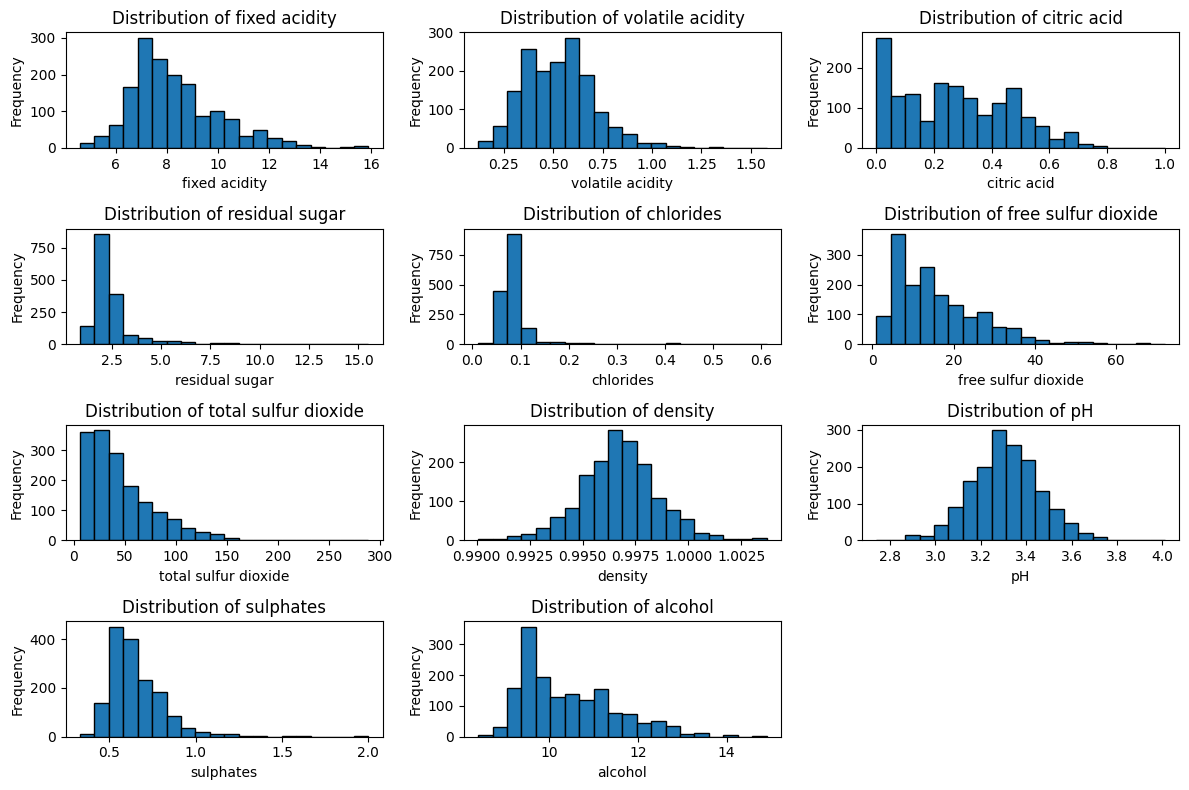

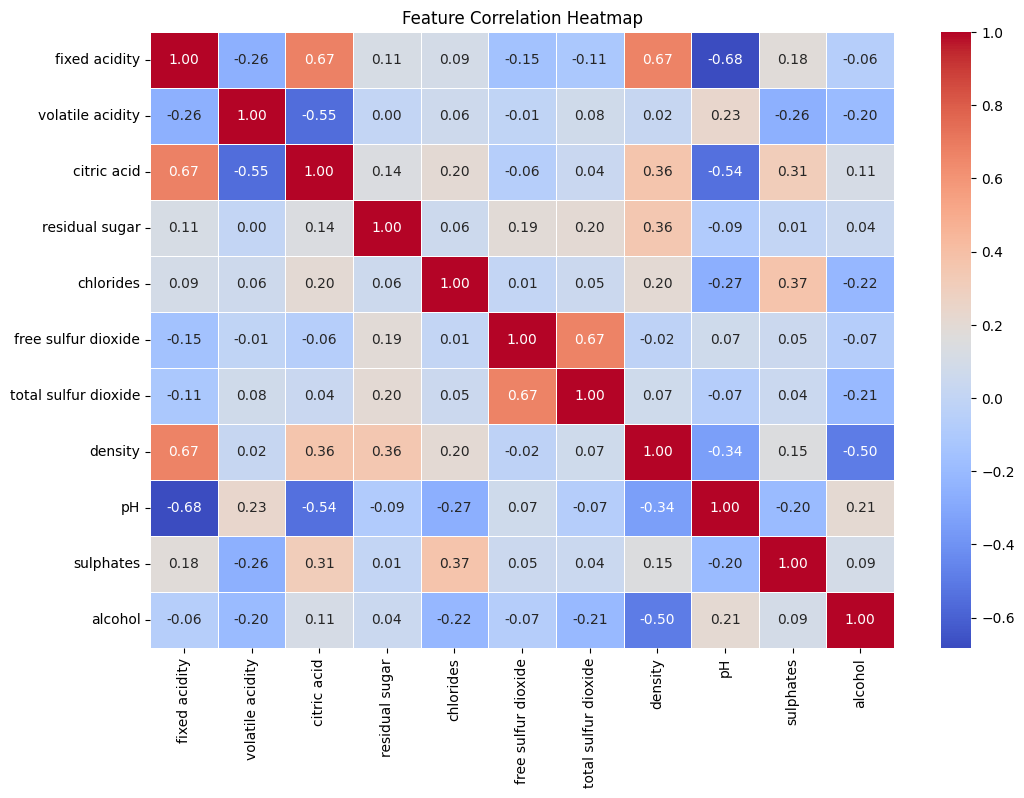

No highly correlated feature pairs found (|correlation| > 0.7).
Negatively Correlated Feature Pairs (|correlation| < -0.5):
fixed acidity and pH: Correlation = -0.68
volatile acidity and citric acid: Correlation = -0.55
citric acid and volatile acidity: Correlation = -0.55
citric acid and pH: Correlation = -0.54
pH and fixed acidity: Correlation = -0.68
pH and citric acid: Correlation = -0.54


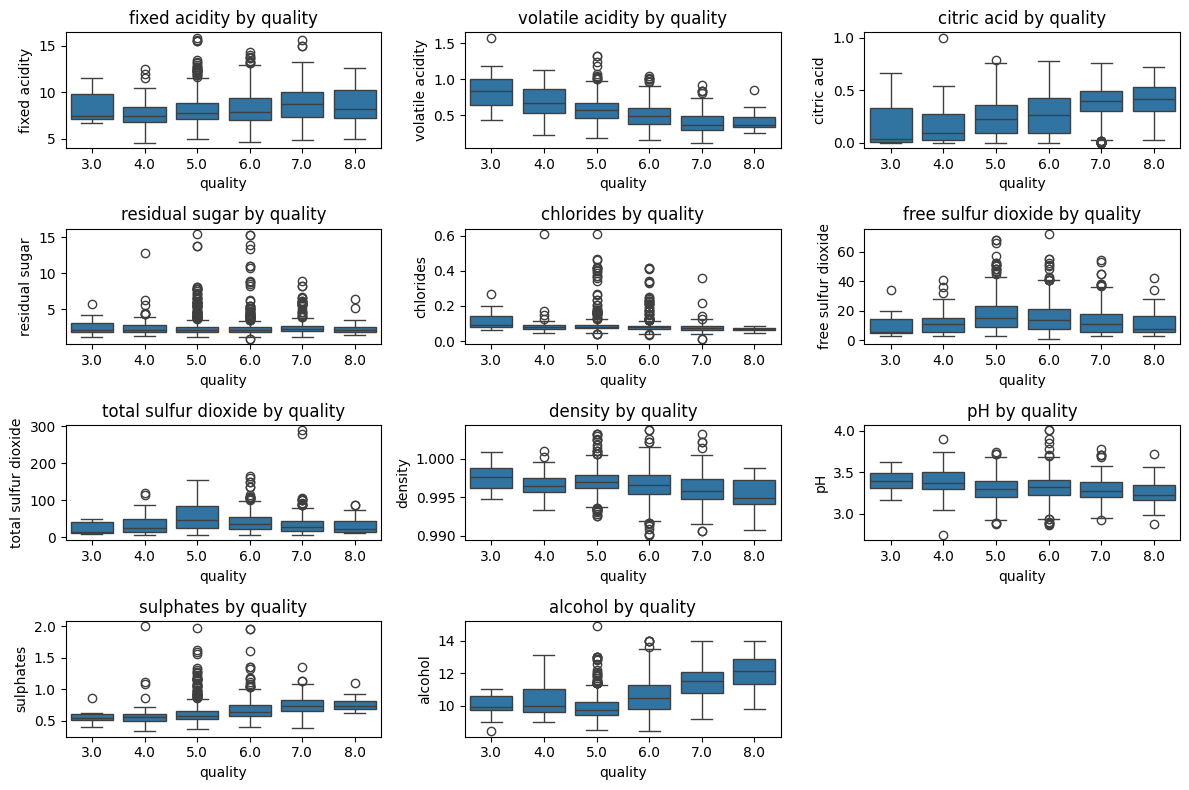

In [58]:
def analyzeNumericFeatures(df, numericFeatures, target):
    if len(numericFeatures) > 0:

        display(df[numericFeatures].describe().T) # transposing the data to make it more readable here

        plt.figure(figsize=(12,8))
        for i,v in enumerate(numericFeatures):
            plt.subplot((len(numericFeatures) + 2) // 3, 3, i + 1)
            plt.hist(df[v], bins=20, edgecolor='k')
            plt.title(f'Distribution of {v}')
            plt.xlabel(v)
            plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12,8))
        corrMatrix=df[numericFeatures].corr()
        sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title('Feature Correlation Heatmap')
        plt.show()

        highCorrleation=corrMatrix.unstack()
        highCorrleation=highCorrleation[(abs(highCorrleation) > 0.7) & (highCorrleation != 1.0)]
        if not highCorrleation.empty:
            print("Highly Correlated Feature Pairs (|correlation| > 0.7):")
            for pair, corrValue in highCorrleation.items():
                print(f"{pair[0]} and {pair[1]}: Correlation = {corrValue:.2f}")
        else:
            print("No highly correlated feature pairs found (|correlation| > 0.7).")

        NegativeCorrelation=corrMatrix.unstack()
        NegativeCorrelation = NegativeCorrelation[NegativeCorrelation < -0.5]
        if not NegativeCorrelation.empty:
            print("Negatively Correlated Feature Pairs (|correlation| < -0.5):")
            for pair, corrValue in NegativeCorrelation.items():
                print(f"{pair[0]} and {pair[1]}: Correlation = {corrValue:.2f}")
        else:
            print("No negatively correlated feature pairs found (|correlation| < -0.5).")

        plt.figure(figsize=(12,8))
        for i,v in enumerate(numericFeatures):
            plt.subplot((len(numericFeatures) + 2) // 3, 3, i + 1)
            sns.boxplot(x=df[target], y=df[v])
            plt.title(f'{v} by {target}')
            plt.xlabel(target)
            plt.ylabel(v)
        plt.tight_layout()
        plt.show()

analyzeNumericFeatures(df, numericFeatures, target)


# Plotting/Visualizing Categorical data:

In [59]:
def analyzeCategoricalFeatures(df, categoricalFeatures, target):
    if len(categoricalFeatures)>0:
        plt.figure(figsize=(15, 12))
        plot_count = 1

        for col in categoricalFeatures:
            unique_count = df[col].nunique()
            
            if unique_count <= 30:
                plt.subplot((len(categoricalFeatures) + 1) // 2, 2, plot_count)
                sns.countplot(data=df, y=col, color='C0', order=df[col].value_counts().index)
                plt.title(f'Distribution of {col}')
                plt.xlabel('Count')
                plt.ylabel(col)
                plot_count += 1
            else:
                print(f"Skipping {col}: Too many unique values ({unique_count}) to plot effectively.")

        plt.tight_layout()
        plt.show()

analyzeCategoricalFeatures(df, categoricalFeatures, target)

# Data Cleaning:

In [60]:
def cleanData(df, numericFeatures, categoricalFeatures, target):
    val=len(df)
    df=df.dropna(subset=[target])
    droppedRowsCount=val-len(df)

    for i in numericFeatures:
        if i in df.columns and df[i].isnull().sum() > 0:
            df[i] = df[i].fillna(df[i].median())

    print(f"Cleaning complete for numerical data. Current shape: {df.shape}")
    df.head()

    columnsToDrop = []
    threshold = 100 

    if len(categoricalFeatures) > 0:
        for i in categoricalFeatures:
            if i in df.columns:
                uniqueCount = df[i].nunique()
                if uniqueCount > threshold:
                    columnsToDrop.append(i)
                else:
                    if df[i].isnull().sum() > 0:
                        df[i] = df[i].fillna(df[i].mode()[0]) 

        df = df.drop(columns=columnsToDrop)

        categoricalFeatures = [c for c in categoricalFeatures if c in df.columns]


        df_encoded = pd.get_dummies(df, columns=categoricalFeatures, drop_first=True)


        print(f"Shape after encoding: {df_encoded.shape}")
        print(df_encoded.head())

cleanData(df, numericFeatures, categoricalFeatures, target)


Cleaning complete for numerical data. Current shape: (1599, 12)
